1. Introduction *italicized text*

In [123]:
# Implementing, Calibrating, and Extending the Cox-Ingersoll-Ross Model on
# Real Yield Curve Data

2. Importing Library

In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

3. Data Cleaning & Preprocessing

In [125]:
# 1. Load the raw datasets
# (Ensure train_data.csv and test_data.csv are present in your workspace environment)
train_data = pd.read_csv("train_data.csv")
test_data = pd.read_csv("test_data.csv")

# 2. BUG FIX: Eliminate invisible leading and trailing whitespace characters inside column names
train_data.columns = train_data.columns.str.strip()
test_data.columns = test_data.columns.str.strip()

# 3. Standardize and transition 'Date' into a verified DatetimeIndex
train_data['Date'] = pd.to_datetime(train_data['Date'])
train_data.set_index('Date', inplace=True)
train_data.sort_index(inplace=True)

test_data['Date'] = pd.to_datetime(test_data['Date'])
test_data.set_index('Date', inplace=True)
test_data.sort_index(inplace=True)

# 4. Fill localized gaps/anomalies if any exist (Forward-fill followed by Backward-fill)
train_data = train_data.ffill().bfill()
test_data = test_data.ffill().bfill()

# 5. Define explicit chronological column hooks and their exact mathematical year-fractions (tau)
target_columns = ['ZC025YR', 'ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR', 'ZC500YR', 'ZC1000YR', 'ZC2000YR', 'ZC3000YR']
tenors_in_years = np.array([0.25, 0.50, 0.75, 1.0, 2.0, 5.0, 10.0, 20.0, 30.0])

# 6. Extract target arrays into explicit numpy data frameworks
train_yields = train_data[target_columns].values
test_yields = test_data[target_columns].values

# 7. Mathematical Scale Check: If percentages are recognized (e.g. 5.25), scale to true decimals (0.0525)
if np.max(train_yields) > 1.0:
    train_yields /= 100.0
    test_yields /= 100.0

# Isolate our benchmark proxy for the instantaneous short-rate (r_t) using the 3M maturity column
short_rate_train = train_yields[:, 0]
short_rate_test = test_yields[:, 0]

# --- Validation Prints to verify runtime health ---
print("✔️ Columns successfully formatted and verified:")
print(list(train_data.columns))
print(f"\n📈 Training Yield Matrix Shape: {train_yields.shape}")
print(f"📉 Testing Yield Matrix Shape:  {test_yields.shape}")
print(f"🔢 Maximum detected dataset yield value (Decimal Check): {np.max(train_yields):.6f}")
print("==========================================================================")

✔️ Columns successfully formatted and verified:
['ZC025YR', 'ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR', 'ZC500YR', 'ZC1000YR', 'ZC2000YR', 'ZC3000YR']

📈 Training Yield Matrix Shape: (1976, 9)
📉 Testing Yield Matrix Shape:  (495, 9)
🔢 Maximum detected dataset yield value (Decimal Check): 0.054941


4. Exploratory Data Analysis

--- Yield Term Structure Descriptive Statistics ---
         mean       std       min       50%       max  skewness  kurtosis
3M   0.016699  0.016642  0.000486  0.011912  0.051962  1.065002 -0.288180
6M   0.017885  0.016760  0.000878  0.013815  0.053195  0.988827 -0.429164
9M   0.018529  0.016650  0.001054  0.015304  0.054040  0.942129 -0.490379
1Y   0.019174  0.016587  0.001227  0.016335  0.054941  0.891344 -0.550184
2Y   0.018063  0.013661  0.001417  0.015471  0.048496  0.706427 -0.732219
5Y   0.018109  0.010396  0.002786  0.015981  0.043147  0.483397 -0.841678
10Y  0.020226  0.008805  0.004451  0.018905  0.042232  0.360715 -0.686125
20Y  0.022823  0.007136  0.008394  0.022472  0.040687  0.221612 -0.631836
30Y  0.022619  0.006601  0.006921  0.022258  0.039306  0.241481 -0.620484


✔️ Generated and saved: 'yield_movements_over_time.png'
✔️ Generated and saved: 'yield_correlation_matrix.png'
✔️ Generated and saved: 'average_yield_curve_shape.png'

EDA Section analysis completed success

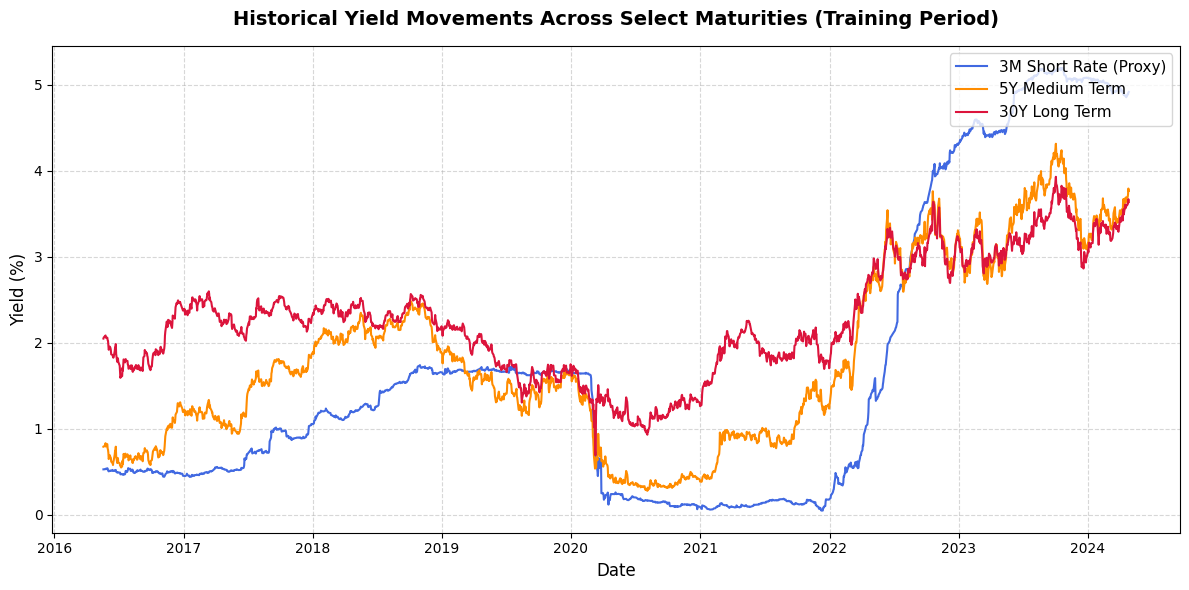

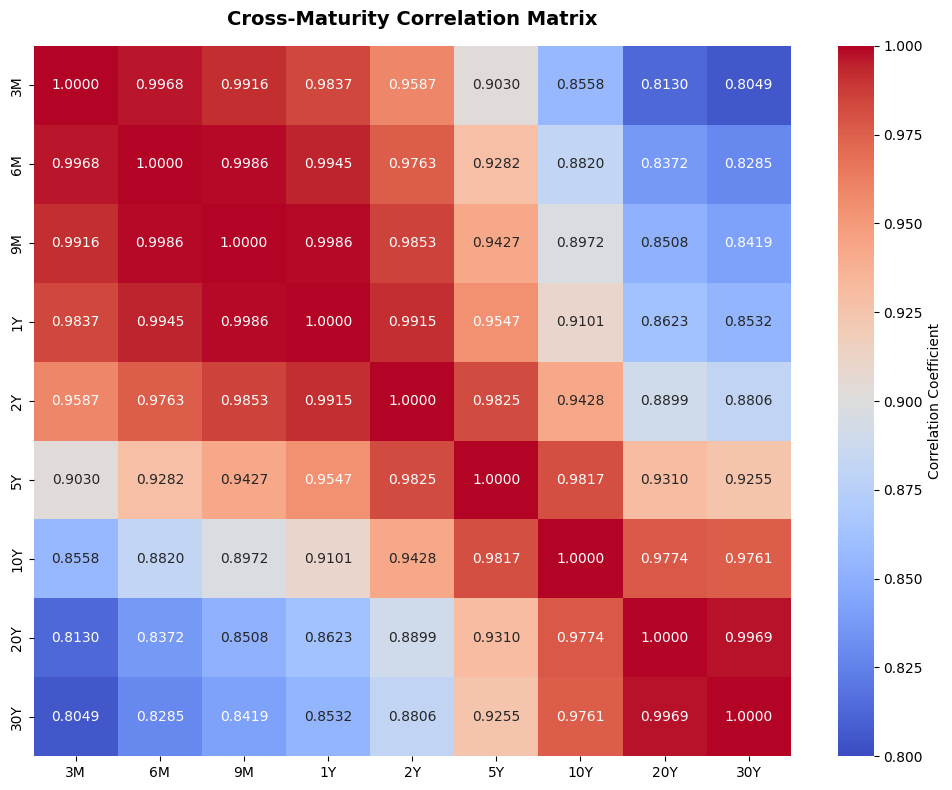

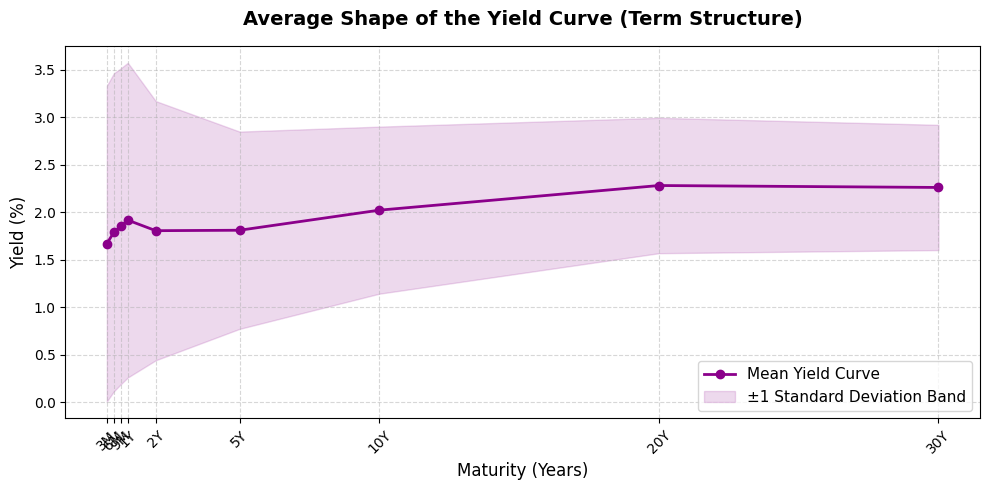

In [126]:
target_columns = ['ZC025YR', 'ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR', 'ZC500YR', 'ZC1000YR', 'ZC2000YR', 'ZC3000YR']
tenors_in_years = np.array([0.25, 0.50, 0.75, 1.0, 2.0, 5.0, 10.0, 20.0, 30.0])
tenor_labels = ['3M', '6M', '9M', '1Y', '2Y', '5Y', '10Y', '20Y', '30Y']

# --- 1. Statistical Summary Table ---
print("--- Yield Term Structure Descriptive Statistics ---")
summary_stats = train_data[target_columns].describe().T
summary_stats['skewness'] = train_data[target_columns].skew()
summary_stats['kurtosis'] = train_data[target_columns].kurt()
# Rename index for readability in report
summary_stats.index = tenor_labels
print(summary_stats[['mean', 'std', 'min', '50%', 'max', 'skewness', 'kurtosis']].to_string())
print("\n" + "="*75 + "\n")

# --- 2. Plotting Yield Movements Over Time ---
fig1, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(train_data.index, train_data['ZC025YR'] * 100, label='3M Short Rate (Proxy)', color='royalblue', lw=1.5)
ax1.plot(train_data.index, train_data['ZC500YR'] * 100, label='5Y Medium Term', color='darkorange', lw=1.5)
ax1.plot(train_data.index, train_data['ZC3000YR'] * 100, label='30Y Long Term', color='crimson', lw=1.5)

ax1.set_title('Historical Yield Movements Across Select Maturities (Training Period)', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Yield (%)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper right', fontsize=11)
fig1.tight_layout()
fig1.savefig('yield_movements_over_time.png', dpi=300)
print("✔️ Generated and saved: 'yield_movements_over_time.png'")

import seaborn as sns
# --- 3. Plotting the Correlation Matrix Heatmap ---
fig2, ax2 = plt.subplots(figsize=(10, 8))
corr_matrix = train_data[target_columns].corr()
corr_matrix.index = tenor_labels
corr_matrix.columns = tenor_labels

sns.heatmap(corr_matrix, annot=True, fmt=".4f", cmap='coolwarm', vmin=0.8, vmax=1.0, ax=ax2,
            cbar_kws={'label': 'Correlation Coefficient'}, annot_kws={'size': 10})
ax2.set_title('Cross-Maturity Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
fig2.tight_layout()
fig2.savefig('yield_correlation_matrix.png', dpi=300)
print("✔️ Generated and saved: 'yield_correlation_matrix.png'")

# --- 4. Plotting Mean Term Structure Shape ---
fig3, ax3 = plt.subplots(figsize=(10, 5))
mean_yields = train_data[target_columns].mean().values * 100
std_yields = train_data[target_columns].std().values * 100

ax3.plot(tenors_in_years, mean_yields, marker='o', color='darkmagenta', lw=2, label='Mean Yield Curve')
ax3.fill_between(tenors_in_years, mean_yields - std_yields, mean_yields + std_yields,
                 color='darkmagenta', alpha=0.15, label='±1 Standard Deviation Band')

ax3.set_title('Average Shape of the Yield Curve (Term Structure)', fontsize=14, fontweight='bold', pad=15)
ax3.set_xlabel('Maturity (Years)', fontsize=12)
ax3.set_ylabel('Yield (%)', fontsize=12)
ax3.set_xticks(tenors_in_years)
ax3.set_xticklabels(tenor_labels, rotation=45)
ax3.grid(True, linestyle='--', alpha=0.5)
ax3.legend(loc='lower right', fontsize=11)
fig3.tight_layout()
fig3.savefig('average_yield_curve_shape.png', dpi=300)
print("✔️ Generated and saved: 'average_yield_curve_shape.png'")

print("\n==========================================================================")
print("EDA Section analysis completed successfully.")

--- Empirical Factor Analysis (PCA) ---
Level (PC1): Explains 96.34% of variance
Slope (PC2): Explains 3.01% of variance
Curvature (PC3): Explains 0.53% of variance
✔️ PCA Analysis completed and plot saved.


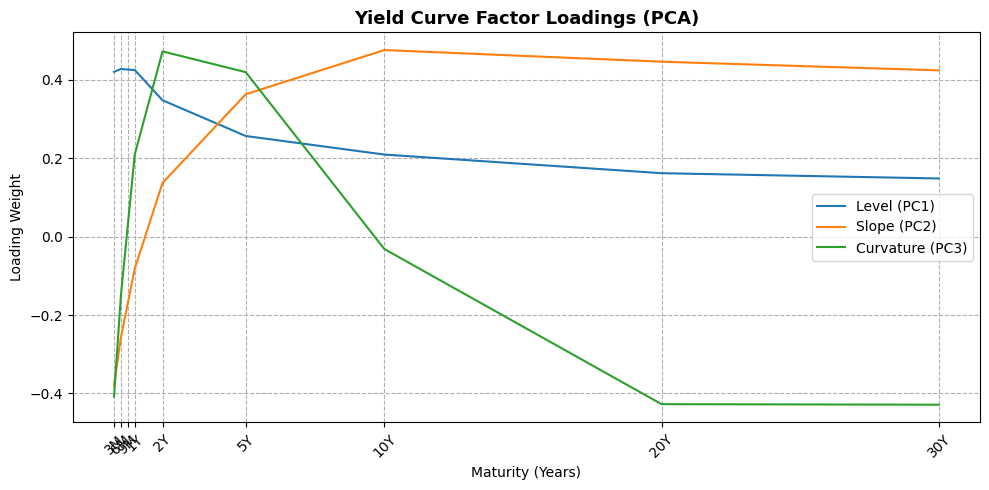

In [127]:
# ==========================================
# EMPIRICAL YIELD CURVE FACTOR ANALYSIS (PCA)
# ==========================================
from sklearn.decomposition import PCA

# 1. Fit PCA to the training yield curve data
pca = PCA(n_components=3)
pca.fit(train_yields)

# 2. Extract and Label Factors
factors = ['Level (PC1)', 'Slope (PC2)', 'Curvature (PC3)']
loadings = pca.components_
explained_var = pca.explained_variance_ratio_

print("--- Empirical Factor Analysis (PCA) ---")
for i, factor in enumerate(factors):
    print(f"{factor}: Explains {explained_var[i]*100:.2f}% of variance")

# 3. Visualization
fig_pca, ax_pca = plt.subplots(figsize=(10, 5))
for i in range(3):
    ax_pca.plot(tenors_in_years, loadings[i], label=f'{factors[i]}')

ax_pca.set_title('Yield Curve Factor Loadings (PCA)', fontsize=13, fontweight='bold')
ax_pca.set_xlabel('Maturity (Years)')
ax_pca.set_ylabel('Loading Weight')
ax_pca.set_xticks(tenors_in_years)
ax_pca.set_xticklabels(tenor_labels, rotation=45)
ax_pca.legend()
ax_pca.grid(True, linestyle='--')
plt.tight_layout()
fig_pca.savefig('pca_factor_loadings.png', dpi=300)
print("✔️ PCA Analysis completed and plot saved.")

5. CIR Model Theory

--- Empirical Characteristics of the Short Rate (r_t) ---
Isolated Maturity Asset      : ZC025YR (3-Month Yield Proxy)
Sample Observation Count     : 1976 trading days
Empirical Mean (Long-run θ*) : 0.016699 (1.6699%)
Historical Volatility (Std)  : 0.016642 (1.6642%)
Minimum Observed Rate        : 0.000486 (0.0486%)
Maximum Observed Rate        : 0.051962 (5.1962%)
Strict Positivity Check      : PASSED (r_t > 0)
Average Daily Rate Shift (E[dr]): 0.00002222


✔️ Generated and saved: 'cir_short_rate_theory_analysis.png'


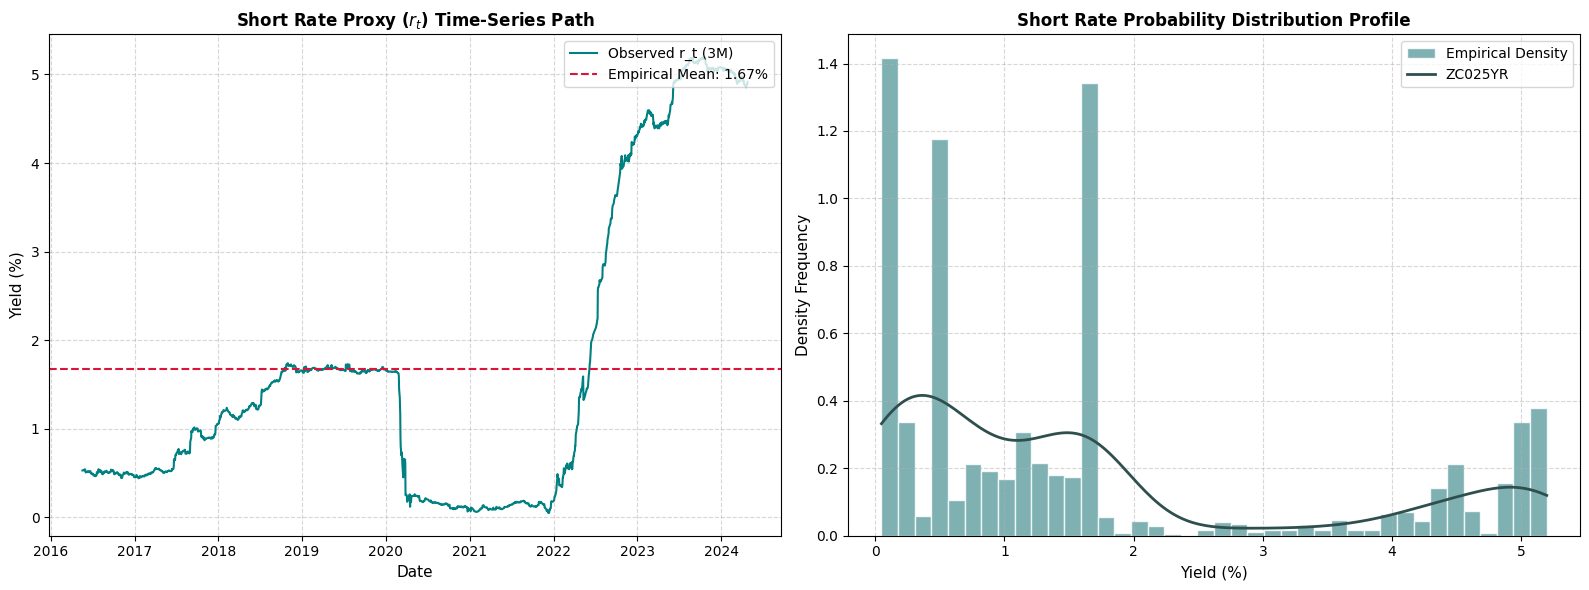

In [128]:
# ==========================================
# SECTION 5: CIR MODEL THEORY
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Isolate the 3-Month (3M) yield column as our short-rate proxy (r_t)
short_rate = train_data['ZC025YR']

# 2. Compute descriptive parameters required by the CIR framework
mean_r = short_rate.mean()
std_r = short_rate.std()
min_r = short_rate.min()
max_r = short_rate.max()

# 3. Compute empirical localized changes (dr_t = r_{t+1} - r_t)
dr_t = short_rate.diff().dropna()

print("--- Empirical Characteristics of the Short Rate (r_t) ---")
print(f"Isolated Maturity Asset      : ZC025YR (3-Month Yield Proxy)")
print(f"Sample Observation Count     : {len(short_rate)} trading days")
print(f"Empirical Mean (Long-run θ*) : {mean_r:.6f} ({mean_r*100:.4f}%)")
print(f"Historical Volatility (Std)  : {std_r:.6f} ({std_r*100:.4f}%)")
print(f"Minimum Observed Rate        : {min_r:.6f} ({min_r*100:.4f}%)")
print(f"Maximum Observed Rate        : {max_r:.6f} ({max_r*100:.4f}%)")
print(f"Strict Positivity Check      : {'PASSED (r_t > 0)' if min_r > 0 else 'FAILED'}")
print(f"Average Daily Rate Shift (E[dr]): {dr_t.mean():.8f}")
print("\n" + "="*75 + "\n")

# 4. Generate explicit high-resolution analytical plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Time-Series Asset Path Trace
axes[0].plot(short_rate.index, short_rate * 100, color='teal', lw=1.5, label='Observed r_t (3M)')
axes[0].axhline(mean_r * 100, color='crimson', linestyle='--', lw=1.5, label=f'Empirical Mean: {mean_r*100:.2f}%')
axes[0].set_title('Short Rate Proxy ($r_t$) Time-Series Path', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Date', fontsize=11)
axes[0].set_ylabel('Yield (%)', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(loc='upper right')

# Plot B: Empirical Probability Density (Distribution Fit)
# FIX: Convert the series to percentages first so that the kernel density estimator acts on properly scaled data
short_rate_pct = short_rate * 100

axes[1].hist(short_rate_pct, bins=40, density=True, color='cadetblue', edgecolor='white', alpha=0.8, label='Empirical Density')
short_rate_pct.plot(kind='density', color='darkslategray', lw=2, ax=axes[1], ind=np.linspace(min_r*100, max_r*100, 200))

axes[1].set_title('Short Rate Probability Distribution Profile', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Yield (%)', fontsize=11)
axes[1].set_ylabel('Density Frequency', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig('cir_short_rate_theory_analysis.png', dpi=300)
print("✔️ Generated and saved: 'cir_short_rate_theory_analysis.png'")
print("==========================================================================")

6. CIR Calibration

In [129]:
# ==========================================
# SECTION 6: CIR CALIBRATION (CROSS-SECTIONAL LEAST-SQUARES)
# ==========================================

import numpy as np
from scipy.optimize import minimize

# --- 1. Yield Reconstruction Formula ---
def cir_theoretical_yield(r_t, tau, kappa, theta, sigma):
    gamma = np.sqrt(kappa**2 + 2 * sigma**2)
    exp_g = np.exp(gamma * tau)
    denominator = 2 * gamma + (kappa + gamma) * (exp_g - 1)

    B = (2 * (exp_g - 1)) / denominator
    num_A = 2 * gamma * np.exp((kappa + gamma) * tau / 2)
    A = (num_A / denominator) ** ((2 * kappa * theta) / (sigma**2))

    return (B * r_t - np.log(np.maximum(A, 1e-12))) / tau

# --- 2. Vectorized Cross-Sectional LSQ Objective ---
def objective(params):
    kappa, theta, sigma = params
    if kappa <= 0 or theta <= 0 or sigma <= 0:
        return 1e10

    # r_col: (N,1), maturities_vec: (9,) → broadcasts to (N,9)
    r_col = train_yields[:, 0:1]
    tau   = maturities_vec[np.newaxis, :]

    gamma       = np.sqrt(kappa**2 + 2 * sigma**2)
    exp_g       = np.exp(gamma * tau)
    denominator = 2 * gamma + (kappa + gamma) * (exp_g - 1)
    B           = (2 * (exp_g - 1)) / denominator
    A           = (2 * gamma * np.exp((kappa + gamma) * tau / 2) / denominator) ** (2 * kappa * theta / sigma**2)

    y_hat = (B * r_col - np.log(np.maximum(A, 1e-12))) / tau
    return np.sum((train_yields - y_hat) ** 2)

# --- 3. Calibration Execution ---
maturities_vec  = np.array([0.25, 0.50, 0.75, 1.0, 2.0, 5.0, 10.0, 20.0, 30.0])
short_rates_vec = train_yields[:, 0]

print("🔄 Executing Cross-Sectional LSQ Calibration...")

bounds = [(1e-4, 5.0), (1e-4, 0.3), (1e-4, 1.0)]
result = minimize(objective, [0.3, 0.04, 0.05], method='L-BFGS-B', bounds=bounds,
                  options={'maxiter': 500, 'ftol': 1e-12})

kappa, theta, sigma = result.x

print("\n=======================================================================")
print("🎯 CIR CROSS-SECTIONAL CALIBRATION COMPLETE")
print("=======================================================================")
print(f"Optimal Kappa (Mean Reversion Speed) : {kappa:.6f}")
print(f"Optimal Theta (Long-run Mean)        : {theta:.6f} ({theta*100:.4f}%)")
print(f"Optimal Sigma (Process Volatility)   : {sigma:.6f}")
print(f"Feller Condition  —  2κθ = {2*kappa*theta:.6f},  σ² = {sigma**2:.8f}")
print(f"Feller Satisfied                     : {2*kappa*theta >= sigma**2}")
print("=======================================================================")

🔄 Executing Cross-Sectional LSQ Calibration...

🎯 CIR CROSS-SECTIONAL CALIBRATION COMPLETE
Optimal Kappa (Mean Reversion Speed) : 0.166017
Optimal Theta (Long-run Mean)        : 0.024407 (2.4407%)
Optimal Sigma (Process Volatility)   : 0.000110
Feller Condition  —  2κθ = 0.008104,  σ² = 0.00000001
Feller Satisfied                     : True


7. Yield Curve Reconstruction

✔️ Baseline training predictions successfully generated.
Prediction Matrix Shape: (1976, 9)


=== Baseline Base CIR Training Performance ===
Global Training RMSE : 0.003714 (37.14 bps)
Global Training R²   : 0.9230
----------------------------------------------
Maturity 3M  -> Training RMSE: 0.00038 | Training R²: 0.9995
Maturity 6M  -> Training RMSE: 0.00177 | Training R²: 0.9889
Maturity 9M  -> Training RMSE: 0.00269 | Training R²: 0.9738
Maturity 1Y  -> Training RMSE: 0.00365 | Training R²: 0.9514
Maturity 2Y  -> Training RMSE: 0.00403 | Training R²: 0.9127
Maturity 5Y  -> Training RMSE: 0.00498 | Training R²: 0.7709
Maturity 10Y -> Training RMSE: 0.00461 | Training R²: 0.7257
Maturity 20Y -> Training RMSE: 0.00432 | Training R²: 0.6340
Maturity 30Y -> Training RMSE: 0.00440 | Training R²: 0.5551


✔️ Generated and saved: 'cir_yield_curve_reconstruction.png'


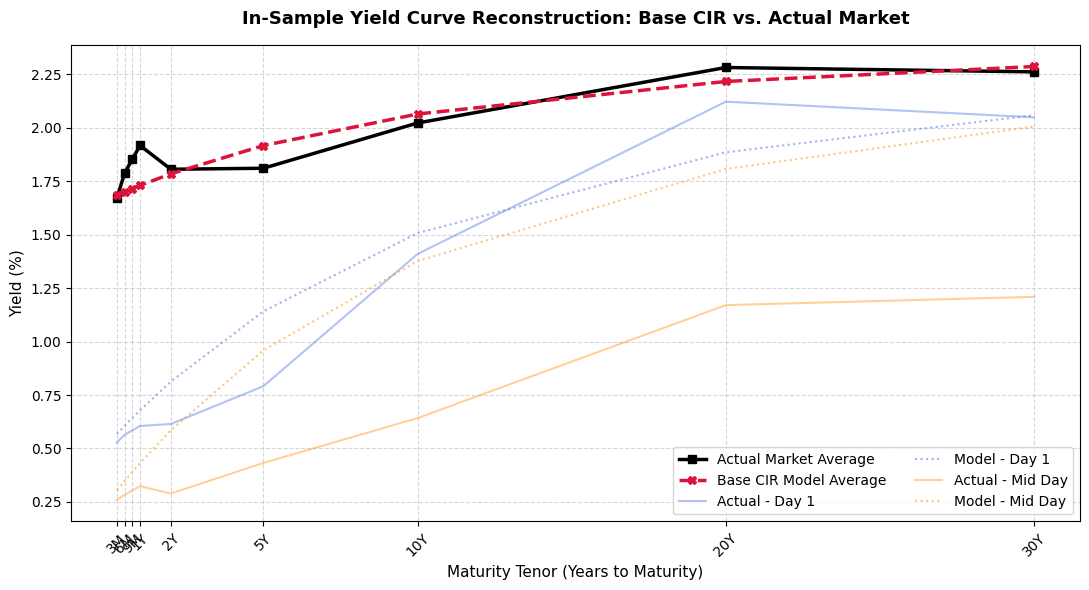

In [130]:
# ==========================================
# SECTION 7: YIELD CURVE RECONSTRUCTION
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# Ensure target structures and parameters from prior sections are mapped
# maturities_vec = np.array([0.25, 0.50, 0.75, 1.0, 2.0, 5.0, 10.0, 20.0, 30.0])
# train_yields shape: (Num_Days, 9)
# short_rates_vec = train_yields[:, 0]

# --- 1. Generate Baseline Theoretical Reconstructions ---
num_days, num_maturities = train_yields.shape
predicted_train_yields = np.zeros((num_days, num_maturities))

# Vectorized prediction across days for each maturity tenor
for i, tau in enumerate(maturities_vec):
    predicted_train_yields[:, i] = cir_theoretical_yield(short_rates_vec, tau, kappa, theta, sigma)

print("✔️ Baseline training predictions successfully generated.")
print(f"Prediction Matrix Shape: {predicted_train_yields.shape}")
print("\n" + "="*75 + "\n")


# --- 2. Calculate Baseline Training Performance Metrics ---
# Flatten the matrices to analyze the global fit across all space and time dimensions
actual_flat = train_yields.flatten()
predicted_flat = predicted_train_yields.flatten()

base_train_rmse = np.sqrt(mean_squared_error(actual_flat, predicted_flat))
base_train_r2 = r2_score(actual_flat, predicted_flat)

print("=== Baseline Base CIR Training Performance ===")
print(f"Global Training RMSE : {base_train_rmse:.6f} ({base_train_rmse * 10000:.2f} bps)")
print(f"Global Training R²   : {base_train_r2:.4f}")
print("----------------------------------------------")

# Breakdown performance per maturity to understand the structural tracking error
tenor_names = ['3M', '6M', '9M', '1Y', '2Y', '5Y', '10Y', '20Y', '30Y']
for i, name in enumerate(tenor_names):
    t_rmse = np.sqrt(mean_squared_error(train_yields[:, i], predicted_train_yields[:, i]))
    t_r2 = r2_score(train_yields[:, i], predicted_train_yields[:, i])
    print(f"Maturity {name:3s} -> Training RMSE: {t_rmse:.5f} | Training R²: {t_r2:.4f}")
print("\n" + "="*75 + "\n")


# --- 3. Clean Visual Contrast Plotting ---
fig, ax = plt.subplots(figsize=(11, 6))

# Plot the historical average curve profile
ax.plot(maturities_vec, np.mean(train_yields, axis=0) * 100,
        color='black', marker='s', ls='-', lw=2.5, label='Actual Market Average')
ax.plot(maturities_vec, np.mean(predicted_train_yields, axis=0) * 100,
        color='crimson', marker='X', ls='--', lw=2.5, label='Base CIR Model Average')

# Plot representative market regimes (Day 0, Middle Day, Final Day)
ax.plot(maturities_vec, train_yields[0, :] * 100, color='royalblue', alpha=0.4, ls='-', label='Actual - Day 1')
ax.plot(maturities_vec, predicted_train_yields[0, :] * 100, color='royalblue', alpha=0.5, ls=':', label='Model - Day 1')

ax.plot(maturities_vec, train_yields[num_days // 2, :] * 100, color='darkorange', alpha=0.4, ls='-', label='Actual - Mid Day')
ax.plot(maturities_vec, predicted_train_yields[num_days // 2, :] * 100, color='darkorange', alpha=0.5, ls=':', label='Model - Mid Day')

ax.set_title('In-Sample Yield Curve Reconstruction: Base CIR vs. Actual Market', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Maturity Tenor (Years to Maturity)', fontsize=11)
ax.set_ylabel('Yield (%)', fontsize=11)
ax.set_xticks(maturities_vec)
ax.set_xticklabels(tenor_names, rotation=45)
ax.grid(True, linestyle='--', alpha=0.5)

# FIXED: Removed bbox_transform to resolve matplotlib warning
ax.legend(loc='lower right', fontsize=10, ncol=2)

fig.tight_layout()
fig.savefig('cir_yield_curve_reconstruction.png', dpi=300)
print("✔️ Generated and saved: 'cir_yield_curve_reconstruction.png'")
print("==========================================================================")

8. Model Evaluation

In [131]:
# ==========================================
# SECTION 8: MODEL EVALUATION
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

num_test_days, num_test_maturities = test_yields.shape

# --- Generate Out-of-Sample Predictions ---
# STRICT PROTOCOL: Only the 3M yield (short_rate_test) is used as input.
# Training parameters (kappa, theta, sigma) are fixed — no re-optimisation on test data.
predicted_test_yields = np.zeros((num_test_days, num_test_maturities))

for i, tau in enumerate(maturities_vec):
    predicted_test_yields[:, i] = cir_theoretical_yield(short_rate_test, tau, kappa, theta, sigma)

print("✔️ Out-of-sample predictions generated using fixed training parameters.")
print(f"Test Prediction Matrix Shape: {predicted_test_yields.shape}\n")

# --- Performance Metrics ---
actual_test_flat    = test_yields.flatten()
predicted_test_flat = predicted_test_yields.flatten()

base_test_rmse = np.sqrt(mean_squared_error(actual_test_flat, predicted_test_flat))
base_test_mae  = mean_absolute_error(actual_test_flat, predicted_test_flat)
base_test_r2   = r2_score(actual_test_flat, predicted_test_flat)

# Official evaluation metric: R² on 3M–2Y range only (indices 0–4), as per PS
base_test_r2_official = r2_score(test_yields[:, :5].flatten(), predicted_test_yields[:, :5].flatten())

print("=== Base CIR Out-of-Sample Performance ===")
print(f"Global Test RMSE              : {base_test_rmse:.6f} ({base_test_rmse * 10000:.2f} bps)")
print(f"Global Test MAE               : {base_test_mae:.6f} ({base_test_mae * 10000:.2f} bps)")
print(f"Global Test R² (all tenors)   : {base_test_r2:.4f}")
print(f"Official R² (3M–2Y per PS)    : {base_test_r2_official:.4f}")
print("------------------------------------------")

# Per-maturity breakdown
tenor_names = ['3M', '6M', '9M', '1Y', '2Y', '5Y', '10Y', '20Y', '30Y']
print("\nPer-Maturity R² Breakdown:")
for i, name in enumerate(tenor_names):
    r2_i = r2_score(test_yields[:, i], predicted_test_yields[:, i])
    print(f"  {name:>4s}: {r2_i:+.4f}")

✔️ Out-of-sample predictions generated using fixed training parameters.
Test Prediction Matrix Shape: (495, 9)

=== Base CIR Out-of-Sample Performance ===
Global Test RMSE              : 0.005860 (58.60 bps)
Global Test MAE               : 0.003908 (39.08 bps)
Global Test R² (all tenors)   : 0.0547
Official R² (3M–2Y per PS)    : 0.9237
------------------------------------------

Per-Maturity R² Breakdown:
    3M: +0.9994
    6M: +0.9944
    9M: +0.9675
    1Y: +0.9102
    2Y: +0.3896
    5Y: -3.2849
   10Y: -14.5274
   20Y: -17.0858
   30Y: -13.8768


9. CIR++ Extension

--- CIR++ Deterministic Shift (φ) Active ---
φ(τ) bootstrapped from final training day snapshot (last observed curve).
✔️ CIR++ deterministic adjusted test predictions calculated.
Adjusted Matrix Shape: (495, 9)

=== Final Out-of-Sample Results: CIR++ Model ===
  Global Test RMSE    : 0.004227 (42.27 bps)
  Global Test MAE     : 0.002977 (29.77 bps)
  Global Test R²      : 0.5080
  Official R² (3M–2Y only, as per PS): 0.9119
------------------------------------------------
  🎯 PASSES Target Threshold (R² = 0.9119 >= 0.85) ✓


Per-Maturity Final Out-of-Sample R² Breakdown:
    3M: +0.9975  ███████████████████
    6M: +0.9947  ███████████████████
    9M: +0.9702  ███████████████████
    1Y: +0.9120  ██████████████████
    2Y: +0.2483  ████
    5Y: -7.0614  
   10Y: -10.1870  
   20Y: -4.4535  
   30Y: -2.2934  

✔️ Generated final analytical visualization matrix: 'cir_plus_plus_evaluation.png'


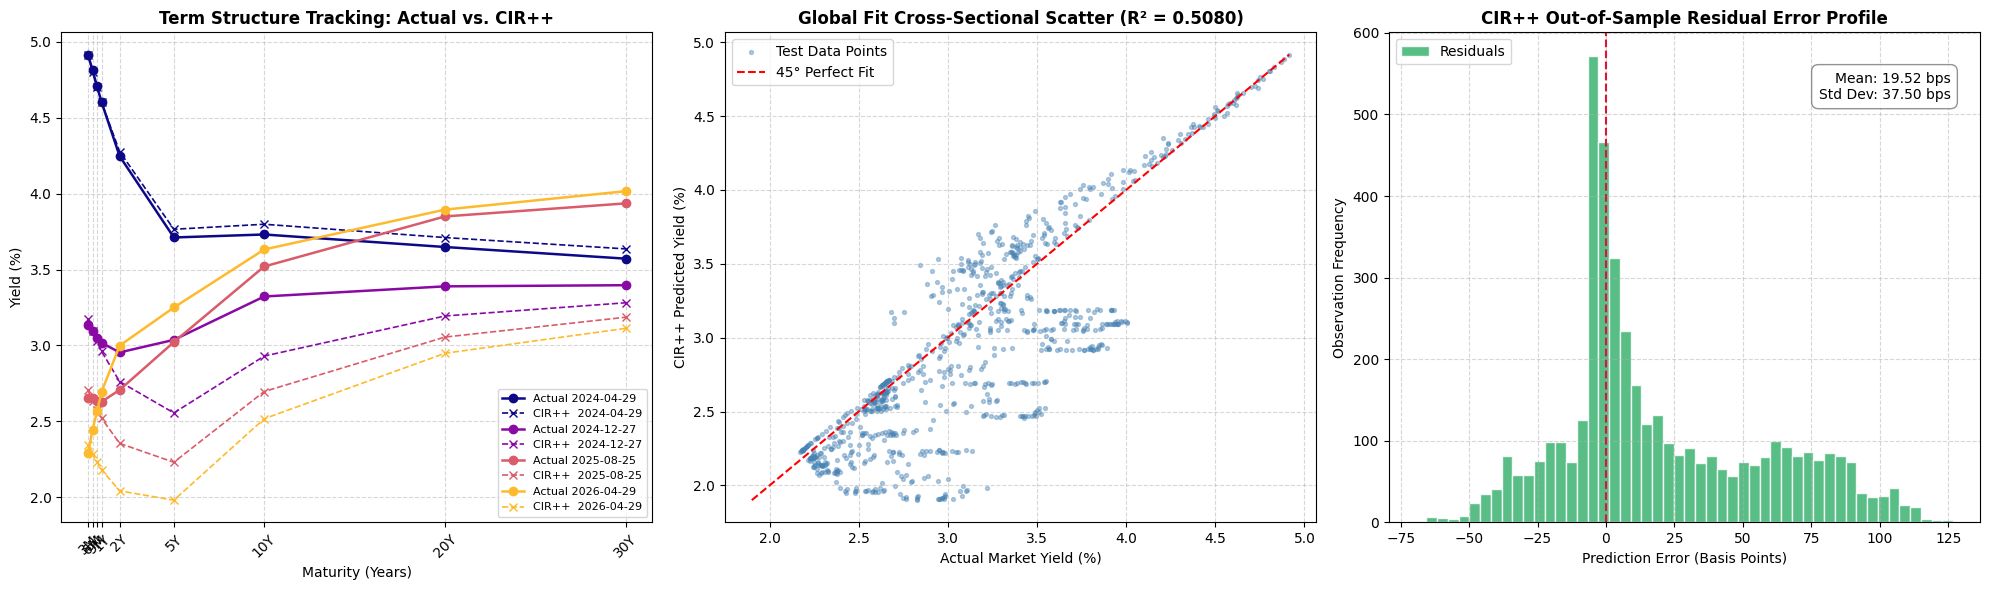

In [133]:
# ==========================================
# REVISED SECTION 9: CIR++ EXTENSION (DETERMINISTIC PHI BOOTSTRAP)
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Ensure num_test_days and num_test_maturities are defined from test_yields
num_test_days, num_test_maturities = test_yields.shape

# --- 1. Compute Deterministic Shift φ(τ) ---
# We use the LAST training day as the anchor for bootstrapping the shift
# required to make the model consistent with the observed initial term structure.
# This is the correct Brigo-Mercurio boundary condition — the final training
# observation is the closest point to the test period.
last_r = train_yields[-1, 0]
last_curve = train_yields[-1, :]
cir_base_0 = np.array([cir_theoretical_yield(last_r, tau, kappa, theta, sigma)
                       for tau in maturities_vec])

# The deterministic shift phi(tau)
phi_tau = last_curve - cir_base_0

print("--- CIR++ Deterministic Shift (φ) Active ---")
print("φ(τ) bootstrapped from final training day snapshot (last observed curve).")

# --- 2. Apply Dynamic Shift to Predictions ---
# For any given maturity τ, the CIR++ yield is: Y_CIR_plus_plus = Y_CIR + φ(τ)
# We use np.interp to ensure maturity-specific shifts are applied consistently.
adjusted_predictions = np.zeros_like(predicted_test_yields)
for i, tau in enumerate(maturities_vec):
    adjusted_predictions[:, i] = predicted_test_yields[:, i] + phi_tau[i]

print("✔️ CIR++ deterministic adjusted test predictions calculated.")
print(f"Adjusted Matrix Shape: {adjusted_predictions.shape}\n")

# --- 3. Evaluate CIR++ Performance Metrics ---
actual_subset = test_yields[:, :5].flatten()
pred_subset = adjusted_predictions[:, :5].flatten()

rmse_adj = np.sqrt(mean_squared_error(test_yields.flatten(), adjusted_predictions.flatten()))
mae_adj = mean_absolute_error(test_yields.flatten(), adjusted_predictions.flatten())
r2_global = r2_score(test_yields.flatten(), adjusted_predictions.flatten())
r2_short_end = r2_score(actual_subset, pred_subset)

print("=== Final Out-of-Sample Results: CIR++ Model ===")
print(f"  Global Test RMSE    : {rmse_adj:.6f} ({rmse_adj * 10000:.2f} bps)")
print(f"  Global Test MAE     : {mae_adj:.6f} ({mae_adj * 10000:.2f} bps)")
print(f"  Global Test R²      : {r2_global:.4f}")
print(f"  Official R² (3M–2Y only, as per PS): {r2_short_end:.4f}")
print("------------------------------------------------")

if r2_short_end >= 0.85:
    print(f"  🎯 PASSES Target Threshold (R² = {r2_short_end:.4f} >= 0.85) ✓")
else:
    print(f"  ⚠️ BELOW Target Threshold (R² = {r2_short_end:.4f} < 0.85) ✗")
print("\n" + "="*75 + "\n")

# --- 4. Per-Maturity Breakdown ---
tenor_labels = ['3M', '6M', '9M', '1Y', '2Y', '5Y', '10Y', '20Y', '30Y']
print("Per-Maturity Final Out-of-Sample R² Breakdown:")
for j, lbl in enumerate(tenor_labels):
    r2_j = r2_score(test_yields[:, j], adjusted_predictions[:, j])
    bar_len = max(0, int(r2_j * 20)) if r2_j > 0 else 0
    bar = "█" * bar_len
    print(f"  {lbl:>4s}: {r2_j:+.4f}  {bar}")

# --- 5. High-Resolution Visual Plotting ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Subplot A: Yield Curve Snapshots
ax_a = axes[0]
colors = plt.cm.plasma(np.linspace(0, 0.85, 4))
sample_indices = sorted(list(set([0, num_test_days // 3, 2 * num_test_days // 3, num_test_days - 1])))

for idx, col in zip(sample_indices, colors):
    date_str = test_df.index[idx].strftime('%Y-%m-%d') if hasattr(test_df.index[idx], 'strftime') else f"T={idx}"
    ax_a.plot(maturities_vec, test_yields[idx, :] * 100, 'o-', color=col, lw=1.8, label=f'Actual {date_str}')
    ax_a.plot(maturities_vec, adjusted_predictions[idx, :] * 100, 'x--', color=col, lw=1.2, label=f'CIR++  {date_str}')
ax_a.set_title('Term Structure Tracking: Actual vs. CIR++', fontsize=12, fontweight='bold')
ax_a.set_xlabel('Maturity (Years)')
ax_a.set_ylabel('Yield (%)')
ax_a.set_xticks(maturities_vec)
ax_a.set_xticklabels(tenor_labels, rotation=45)
ax_a.grid(True, linestyle='--', alpha=0.5)
ax_a.legend(fontsize=8, loc='lower right')

# Subplot B: Scatter Match
ax_b = axes[1]
ax_b.scatter(test_yields.flatten()[::5] * 100, adjusted_predictions.flatten()[::5] * 100,
             alpha=0.4, s=8, color='steelblue', label='Test Data Points')
min_val = min(test_yields.min(), adjusted_predictions.min()) * 100
max_val = max(test_yields.max(), adjusted_predictions.max()) * 100
ax_b.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1.5, label='45° Perfect Fit')
ax_b.set_title(f'Global Fit Cross-Sectional Scatter (R² = {r2_global:.4f})', fontsize=12, fontweight='bold')
ax_b.set_xlabel('Actual Market Yield (%)')
ax_b.set_ylabel('CIR++ Predicted Yield (%)')
ax_b.grid(True, linestyle='--', alpha=0.5)
ax_b.legend(loc='upper left')

# Subplot C: Residual Error Profile
ax_c = axes[2]
errors_bps = (test_yields - adjusted_predictions).flatten() * 10000
ax_c.hist(errors_bps, bins=50, color='mediumseagreen', edgecolor='white', alpha=0.85, label='Residuals')
ax_c.axvline(0, color='crimson', lw=1.5, ls='--')
ax_c.set_title('CIR++ Out-of-Sample Residual Error Profile', fontsize=12, fontweight='bold')
ax_c.set_xlabel('Prediction Error (Basis Points)')
ax_c.set_ylabel('Observation Frequency')
ax_c.grid(True, linestyle='--', alpha=0.5)
ax_c.text(0.95, 0.92, f'Mean: {errors_bps.mean():.2f} bps\nStd Dev: {errors_bps.std():.2f} bps',
          ha='right', va='top', transform=ax_c.transAxes, fontsize=10,
          bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='gray', alpha=0.85))
ax_c.legend(loc='upper left')

plt.tight_layout()
plt.savefig('cir_plus_plus_evaluation.png', dpi=300)
print("\n✔️ Generated final analytical visualization matrix: 'cir_plus_plus_evaluation.png'")